In [ ]:
import s3dis_sam3d as s3d
# 如需首次配置，请取消注释并换成自己的数据路径：
# s3d.configure(s23dis_root="/path/to/Stanford2D3DS", bimsync_root="/path/to/BIMSyn")
print(s3d.CONFIG)

In [ ]:
import s3dis_sam3d as s3d
from s3dis_sam3d import Matterport3DDataset, BIMNetDataset
mp3d_dataset = Matterport3DDataset()
bimnet_dataset = BIMNetDataset()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
import numpy as np
scene = "1pXnuDYAj8r"
mp3d_scene = mp3d_dataset.get_scene(scene)
bim_scene = bimnet_dataset[scene]

mesh = bim_scene.mesh(
        )
num = 0
for frame in mp3d_scene.frames:
        gt = np.asarray(frame.depth, dtype=np.float32)
        if not bim_scene.is_contained_in(frame):
                continue
        gt_valid_fraction = float((np.isfinite(gt) & (gt > 0)).mean())
        if gt_valid_fraction < 0.1:
                continue
        bim_depth = bim_scene.render_depth(frame)
        bim_hit_fraction = float((bim_depth > 0).mean())
        if bim_hit_fraction < 0.2:
                continue
        
        num += 1
print(f"Scene {scene}: {num} frames with valid depth and BIM hits")

Scene 1pXnuDYAj8r: 793 frames with valid depth and BIM hits


In [ ]:
from s3dis_sam3d import MP3D_BIMDataset
MP3D_dataset = MP3D_BIMDataset()
print(MP3D_dataset)
print("scenes:", MP3D_dataset.scene_ids)

In [ ]:
scene_id = "hxp"
print("valid samples:", MP3D_dataset.scene_size(scene_id))
mp3d_sample = MP3D_dataset.get(scene_id, 0)
print({key: mp3d_sample[key].shape for key in ("rgb", "gt_depth", "bim_depth", "bim_mask")})

In [1]:
from s3dis_sam3d import S23_BIMDataset

# 默认从 S3-SAM3D-ToolKit/dataset/ifc_to_s3dis/Area_1 加载校准。
# full_scene=True 时首次渲染会加载全部 BIM scene，后续帧复用同一缓存。
S23_dataset = S23_BIMDataset(area="Area_1", full_scene=False)
print(S23_dataset)
print("scenes:", S23_dataset.scene_ids)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
S23_BIMDataset(area='Area_1', scenes=44, indexed_scenes=0, indexed_samples=0)
scenes: ('WC_1', 'conferenceRoom_1', 'conferenceRoom_2', 'copyRoom_1', 'hallway_1', 'hallway_2', 'hallway_3', 'hallway_4', 'hallway_5', 'hallway_6', 'hallway_7', 'hallway_8', 'office_1', 'office_10', 'office_11', 'office_12', 'office_13', 'office_14', 'office_15', 'office_16', 'office_17', 'office_18', 'office_19', 'office_2', 'office_20', 'office_21', 'office_22', 'office_23', 'office_24', 'office_25', 'office_26', 'office_27', 'office_28', 'office_29', 'office_3', 'office_30', 'office_31', 'office_4', 'office_5', 'office_6', 'office_7', 'office_8', 'office_9', 'pantry_1')


In [ ]:
scene_id = "hallway_4"
# print("valid samples:", S23_dataset.scene_size(scene_id))
s23_sample = S23_dataset.get(scene_id, 0)
# print({key: s23_sample[key].shape for key in ("rgb", "gt_depth", "bim_depth", "bim_mask")})
# print(s23_sample["frame_id"], s23_sample["uuid"], s23_sample["gt_valid_fraction"], s23_sample["bim_hit_fraction"])
# print("BIM valid pixels:", s23_sample["bim_mask"].sum())

valid samples: 17


In [13]:
from s3dis_sam3d import MP3D_BIMDataset
dataset = MP3D_BIMDataset()
print("Matterport3D dataset:", dataset.scene_ids)
print(dataset.get(dataset.scene_ids[0], 0).keys())

Matterport3D dataset: ('train/1px', 'train/759', 'train/7y3_1', 'train/ac2', 'train/b6b', 'train/e9z', 'train/hxp', 'train/i5n', 'train/i5n_1', 'train/px4_1', 'train/s9h', 'train/skl', 'train/sn8', 'train/st4', 'train/ur6', 'train/vt2', 'train/vt2_1', 'train/vvo', 'test/7y3', 'test/d7n', 'test/e9z_1', 'test/px4', 'test/px4_2', 'test/q9v', 'test/zsn')
dict_keys(['rgb', 'bim_depth', 'gt_depth', 'bim_mask', 'frame_id', 'bim_scene_id', 'source_scene_id', 'mp3d_scene_id', 'gt_valid_fraction', 'bim_hit_fraction'])


In [ ]:
print("S23-BIM dataset:", dataset.scene_ids[2])
print(len(dataset.scene_samples("train/7y3_1")))
print(len(dataset.scene_samples("test/7y3")))
dataset.get("train/7y3_1", 0)

S23-BIM dataset: train/7y3_1
806
418


In [20]:
dataset.scene_samples(dataset.scene_ids[2])

[{'frame': MatterportFrame(rgb_path=PosixPath('/mnt/priorbimda-data/PriorBIMDA-Datasets/Matterport3D/v1/scans/7y3sRwLe3Va/undistorted_color_images/0662f8da68b94d83a47af1e38f28f4e5_i0_0.jpg'), depth_path=PosixPath('/mnt/priorbimda-data/PriorBIMDA-Datasets/Matterport3D/v1/scans/7y3sRwLe3Va/undistorted_depth_images/0662f8da68b94d83a47af1e38f28f4e5_d0_0.png'), scene_id='7y3sRwLe3Va', panorama_id='0662f8da68b94d83a47af1e38f28f4e5', camera_index=0, yaw_index=0, intrinsics=array([[1.07254e+03, 0.00000e+00, 6.33884e+02],
         [0.00000e+00, 1.07361e+03, 5.15364e+02],
         [0.00000e+00, 0.00000e+00, 1.00000e+00]], dtype=float32), camera_to_world=array([[ 9.99197e-01,  2.85301e-02,  2.81779e-02, -1.03930e+01],
         [-4.00505e-02,  6.75335e-01,  7.36424e-01, -7.22916e+00],
         [ 1.98053e-03, -7.36960e-01,  6.75934e-01,  6.70762e-01],
         [ 0.00000e+00,  0.00000e+00,  0.00000e+00,  1.00000e+00]],
        dtype=float32), distortion=None, undistorted=True),
  'bim_scene_key': 't

In [12]:
print(dataset.get("1pXnuDYAj8r", 3).keys())


dict_keys(['rgb', 'bim_depth', 'gt_depth', 'bim_mask', 'frame_id', 'bim_scene_id', 'source_scene_id', 'mp3d_scene_id', 'gt_valid_fraction', 'bim_hit_fraction'])


In [6]:
from s3dis_sam3d import S23_BIMDataset
dataset = S23_BIMDataset()
print("S23-BIM dataset:", dataset.scene_ids)

S23-BIM dataset: ('WC_1', 'conferenceRoom_1', 'conferenceRoom_2', 'copyRoom_1', 'hallway_1', 'hallway_2', 'hallway_3', 'hallway_4', 'hallway_5', 'hallway_6', 'hallway_7', 'hallway_8', 'office_1', 'office_10', 'office_11', 'office_12', 'office_13', 'office_14', 'office_15', 'office_16', 'office_17', 'office_18', 'office_19', 'office_2', 'office_20', 'office_21', 'office_22', 'office_23', 'office_24', 'office_25', 'office_26', 'office_27', 'office_28', 'office_29', 'office_3', 'office_30', 'office_31', 'office_4', 'office_5', 'office_6', 'office_7', 'office_8', 'office_9', 'pantry_1')


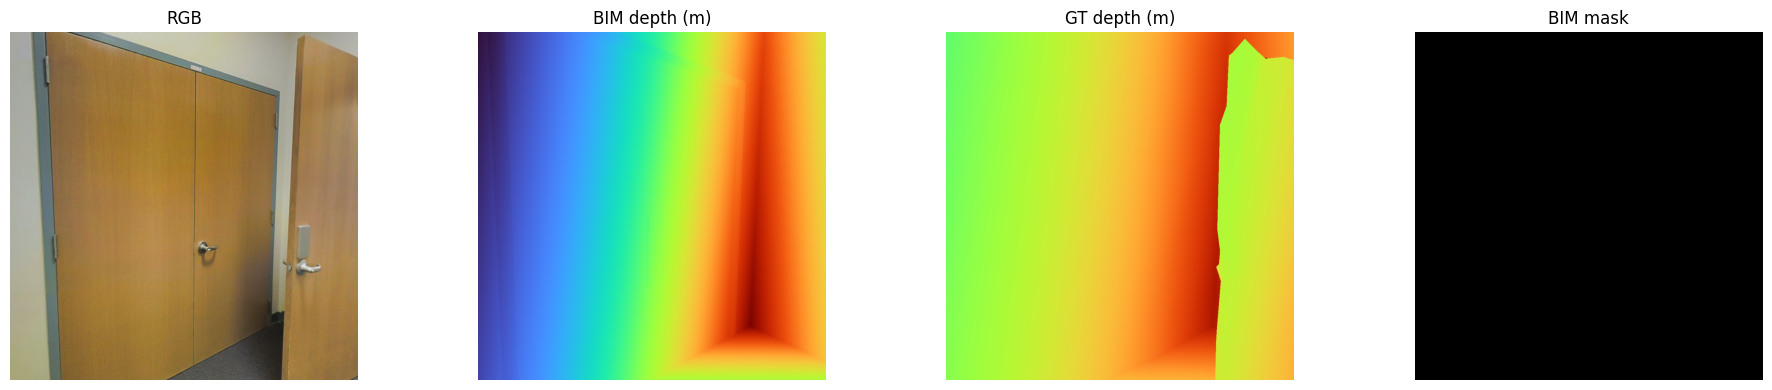

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(19, 4))
axes[0].imshow(s23_sample["rgb"])
axes[0].set_title("RGB")
axes[1].imshow(s23_sample["bim_depth"], cmap="turbo")
axes[1].set_title("BIM depth (m)")
axes[2].imshow(s23_sample["gt_depth"], cmap="turbo")
axes[2].set_title("GT depth (m)")
axes[3].imshow(s23_sample["bim_mask"], cmap="gray")
axes[3].set_title("BIM mask")
for axis in axes:
    axis.axis("off")
plt.tight_layout()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


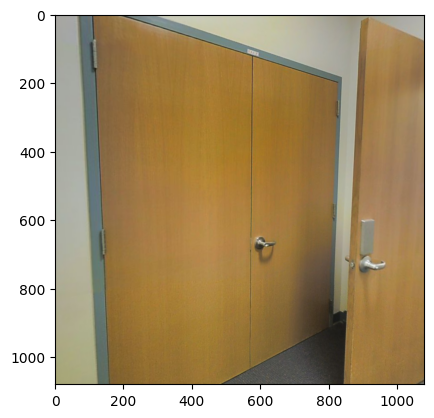

In [1]:
from s3dis_sam3d import S23Dataset
from matplotlib import pyplot as plt
import numpy as np
dataset = S23Dataset()
rgb = dataset.get_scene("hallway_4").frames[0].rgb
plt.imshow(rgb.astype(np.uint8))
plt.show()


In [7]:
def to_semancit_path(rgb_path):
    semantic_path = (
    rgb_path.parent.parent
    / "semantic"
    / rgb_path.name.replace("_rgb.png", "_semantic.png")
)
    return semantic_path
to_semancit_path(dataset.get_scene("hallway_4").frames[0].rgb_path)
from s3dis_sam3d import decode_semantic_labels
b = decode_semantic_labels(to_semancit_path(dataset.get_scene("hallway_4").frames[0].rgb_path))

In [17]:
a=dataset.get_scene("hallway_4").frames[0].rgb_path

In [6]:
c = dataset.get_scene("hallway_4").frames[0].semantic_labels

In [10]:
sum(b - c)

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

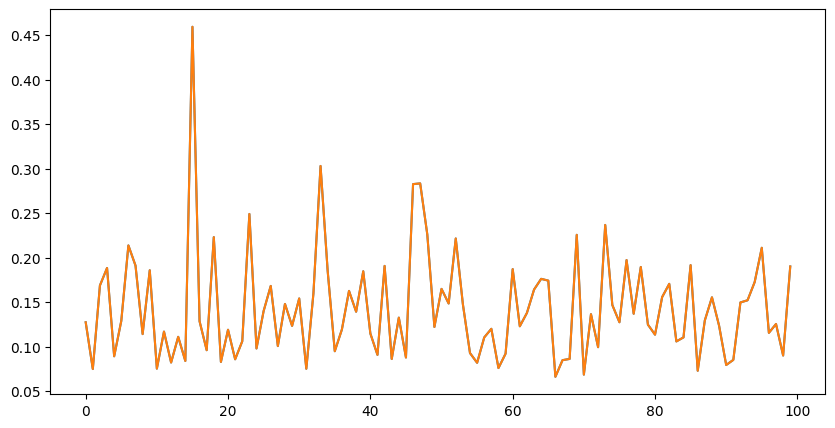

In [2]:
import numpy as np
import matplotlib.pyplot as plt

path = "outputs/full_deterministic_raw1/loss_log.npy"
path1 = "outputs/full_deterministic_raw2/loss_log.npy"

loss_log = np.load(path, allow_pickle=True)
loss_log1 = np.load(path1, allow_pickle=True)

plt.figure(figsize=(10, 5))
plt.plot(loss_log, label="Run 1")
plt.plot(loss_log1, label="Run 2")

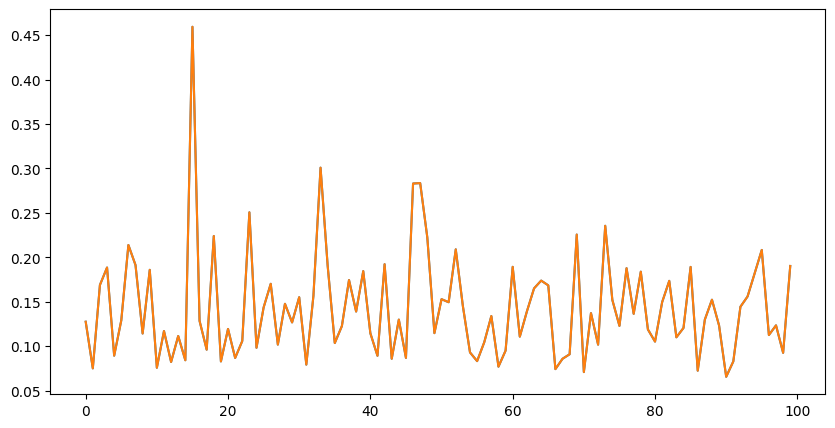

In [13]:
import numpy as np
import matplotlib.pyplot as plt

path = "outputs/3/loss_log.npy"
path1 = "outputs/4/loss_log.npy"

loss_log = np.load(path, allow_pickle=True)
loss_log1 = np.load(path1, allow_pickle=True)

plt.figure(figsize=(10, 5))
plt.plot(loss_log, label="Run 1")
plt.plot(loss_log1, label="Run 2")